# 1. 밴디트 문제
## 1.3 밴디트 알고리즘

In [2]:
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 33.1 MB/s eta 0:00:00a 0:00:01


In [8]:
import numpy as np

np.random.seed(0)
rewards = []

for n in range(1, 11): # 10번 플레이
    reward = np.random.rand() # 무작위 수로 시뮬레이션을 돌린 보상
    rewards.append(reward)
    Q = sum(rewards) / n
    print(Q)

0.5488135039273248
0.6320014351498722
0.6222554154571294
0.6029123573420713
0.567060845741438
0.5801997236289743
0.5598265075766483
0.6013198192273272
0.6415801460355164
0.6157662833145425


### 표본 평균을 효율적으로 구하는 코드

In [9]:
Q = 0

for n in range(1, 11):
    reward = np.random.rand()
    Q = Q + (reward - Q) / n ## reward를 그대로 쓰는건 예제라서?
    print(Q)

0.7917250380826646
0.6603099789177845
0.6295548396431672
0.7035652893055406
0.5770594430840099
0.49540441918693173
0.4275207017945595
0.4781580947637318
0.5114912787844116
0.5473433657306523


## 1.4 밴디트 알고리즘 구현

In [10]:
np.random.rand(10)

array([0.97861834, 0.79915856, 0.46147936, 0.78052918, 0.11827443,
       0.63992102, 0.14335329, 0.94466892, 0.52184832, 0.41466194])

### 슬롯머신 구현

In [11]:
import numpy as np

class Bandit:
    def __init__(self, arms = 10): # arms: 슬롯머신 대수
        self.rates = np.random.rand(arms)
    
    def play(self, arm):
        rate = self.rates[arm]
        if rate > np.random.rand():
            return 1
        else:
            return 0

In [12]:
bandit = Bandit()

for i in range(3):
    print(bandit.play(0))

0
0
0


### 에이전트 구현

In [14]:
bandit = Bandit()
Qs = np.zeros(10)
ns = np.zeros(10)

for n in range(10):
    action = np.random.randint(0, 10)
    reward = bandit.play(action)
    
    ns[action] += 1
    Qs[action] += (reward - Qs[action]) / ns[action]
    print(Qs)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


In [ ]:
class Agent:
    def __init__(self, epsilon, action_size=10):
        self.epsilon = epsilon
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)
        
    def update(self, action, reward):
        self.ns[action] += 1 # n이 점점 커지는 거니까 가치추정을 할 수록 업데이트가 작다.
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]
        
    def get_action(self): # 
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs) ## 탐욕 행동 선택, Q(가치추정치)가 가장 큰 슬롯머신 선택.

In [19]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


858


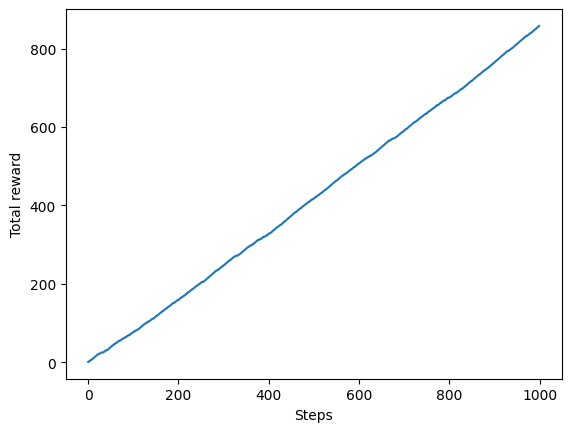

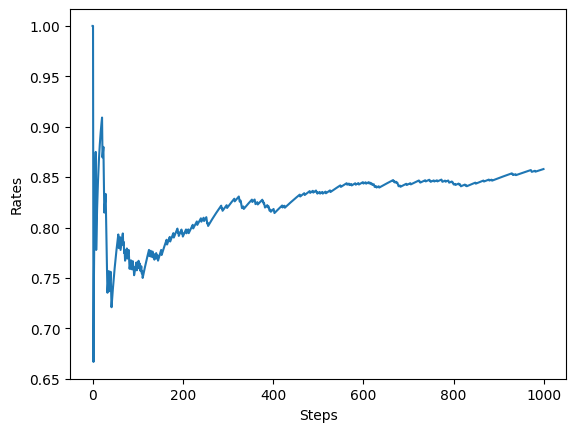

In [30]:
steps = 1000
epsilon = 0.1

bandit = Bandit()
agent = Agent(epsilon)
total_reward = 0
total_rewards = [] # 보상의 합
rates = [] # 승률

for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)
    total_reward += reward
    
    total_rewards.append(total_reward)
    rates.append(total_reward / (step+1)) 
    
print(total_reward)

## 단계별 보상의 총합
plt.ylabel('Total reward')
plt.xlabel('Steps')
plt.plot(total_rewards)
plt.show()

## 단계별 승률
plt.ylabel('Rates')
plt.xlabel('Steps')
plt.plot(rates)
plt.show()

- ϵ의 값으로 '활용과 탐색의 균형'을 조절할 수 있습니다. 

## 1.5 비정상 문제